<a href="https://colab.research.google.com/github/ivannarch865/ivannarichards5to/blob/main/Exploring_Cervical_Cancer_Risk_Factors_Patient_Characteristics_and_Biopsy_Results.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**Exploring Cervical Cancer Risk Factors: Patient Characteristics and Biopsy Results**

##Table of Contents

1. [Description of the Dataset](#scrollTo=5z4oi3lIgqIC)
2. [Initial Setup](#scrollTo=DAsZ5vn0XoIJ)
3. [How common are smoking, hormonal contraceptive use, IUD use, and a history of STIs among patients in this dataset?](#scrollTo=WGDWMz1DYikF)
- `Bar Chart`
4. [How different is the percentage of positive biopsy results between patients with and without a reported history of STIs?](#scrollTo=KRfcCnLOYia8)
- `Pie Chart`


##1. [Description of the Dataset](#scrollTo=43hJ2_zQXoFU)

-  **Source:** UCI Machine Learning Repository, dataset *"Cervical Cancer (Risk Factors)"*.


- **Context:** Data of pacients from Hospital Universitario from Caracas, Venezuela, gathered to study certain factors related to cervical cancer.
- **Observations:** 858 patients.
- **Variables:** 36 columns of demographic information, habits, medical history, and test results.
- **Unit of Observation:** Each row represents one patient.
- **Data type:** Tabular data with numerical and categorical variables. Some categorical variables are binary variables.
- **Missing values:** Some values are missing and marked with `?`. These will be handled during the cleaning process of the analysis.



###Variables of Interest For the First Delivery (2 Research Questions)

- `Smokes`: Whether the patient reports smoking. It is categorical variable (1=yes,0=no).
- `Hormonal Contraceptives` : Whether the patient reports using hormonal contraceptives. It is a categorical variable (1=yes, 0=no)
- `IUD`: Whether the patient reports using intrauterine device, IUD. It is a categorical variable (1=yes, 0=no)
- `STDs`: Whether the pateitn reports a history of sexually transmitted infections, STIs. It is a categorical variable (1=yes, 0=no).
- `Biopsy`: The recorded biopsy result. It is a categorical variable (1=yes, 0=no)



##1. [Initial Setup](#scrollTo=43hJ2_zQXoFU)

In [2]:
file_path="https://raw.githubusercontent.com/ivannarch865/ivannarichards5to/refs/heads/main/risk_factors_cervical_cancer.csv"
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
df=pd.read_csv(file_path)
df.head()

,Age,Number of sexual partners,First sexual intercourse,Num of pregnancies,Smokes,Smokes (years),Smokes (packs/year),Hormonal Contraceptives,Hormonal Contraceptives (years),IUD,...,STDs: Time since first diagnosis,STDs: Time since last diagnosis,Dx:Cancer,Dx:CIN,Dx:HPV,Dx,Hinselmann,Schiller,Citology,Biopsy
0,18,4.0,15.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,?,?,0,0,0,0,0,0,0,0
1,15,1.0,14.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,?,?,0,0,0,0,0,0,0,0
2,34,1.0,?,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,?,?,0,0,0,0,0,0,0,0
3,52,5.0,16.0,4.0,1.0,37.0,37.0,1.0,3.0,0.0,...,?,?,1,0,1,0,0,0,0,0
4,46,3.0,21.0,4.0,0.0,0.0,0.0,1.0,15.0,0.0,...,?,?,0,0,0,0,0,0,0,0


In [3]:
na_values=['?']
df=pd.read_csv(file_path,na_values=na_values)
df.head()

,Age,Number of sexual partners,First sexual intercourse,Num of pregnancies,Smokes,Smokes (years),Smokes (packs/year),Hormonal Contraceptives,Hormonal Contraceptives (years),IUD,...,STDs: Time since first diagnosis,STDs: Time since last diagnosis,Dx:Cancer,Dx:CIN,Dx:HPV,Dx,Hinselmann,Schiller,Citology,Biopsy
0,18,4.0,15.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,NaN,NaN,0,0,0,0,0,0,0,0
1,15,1.0,14.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,NaN,NaN,0,0,0,0,0,0,0,0
2,34,1.0,NaN,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,NaN,NaN,0,0,0,0,0,0,0,0
3,52,5.0,16.0,4.0,1.0,37.0,37.0,1.0,3.0,0.0,...,NaN,NaN,1,0,1,0,0,0,0,0
4,46,3.0,21.0,4.0,0.0,0.0,0.0,1.0,15.0,0.0,...,NaN,NaN,0,0,0,0,0,0,0,0


In [4]:
df.shape

(858, 36)

In [5]:
data = df.rename(columns={
    'Smokes': 'smokes',
    'Hormonal Contraceptives': 'hormonal_contraceptives',
    'IUD': 'iud',
    'STDs': 'stds',
    'Biopsy': 'biopsy'
})

In [6]:
data = data.loc[:, ['smokes', 'hormonal_contraceptives', 'iud', 'stds', 'biopsy']]

data.head()

,smokes,hormonal_contraceptives,iud,stds,biopsy
0,0.0,0.0,0.0,0.0,0
1,0.0,0.0,0.0,0.0,0
2,0.0,0.0,0.0,0.0,0
3,1.0,1.0,0.0,0.0,0
4,0.0,1.0,0.0,0.0,0


In [7]:
data.isnull().sum()

,0
smokes,13
hormonal_contraceptives,108
iud,117
stds,105
biopsy,0


In [8]:
data_clean = data.dropna()

data_clean.shape

(726, 5)

##2. [How common are smoking, hormonal contraceptive use, IUD use, and a history of STIs among patients in this dataset?](#scrollTo=43hJ2_zQXoFU)

In [9]:
data_sum = pd.DataFrame()
data_sum['yes'] = data_clean.sum()
data_sum['responses'] = data_clean.count()

data_sum

,yes,responses
smokes,104.0,726
hormonal_contraceptives,466.0,726
iud,81.0,726
stds,68.0,726
biopsy,50.0,726


In [10]:
plot_data = data_sum.loc[
    ['smokes', 'hormonal_contraceptives', 'iud', 'stds']]

plot_data = plot_data.sort_values('yes')

plot_data

,yes,responses
stds,68.0,726
iud,81.0,726
smokes,104.0,726
hormonal_contraceptives,466.0,726


(0.0, 500.0)

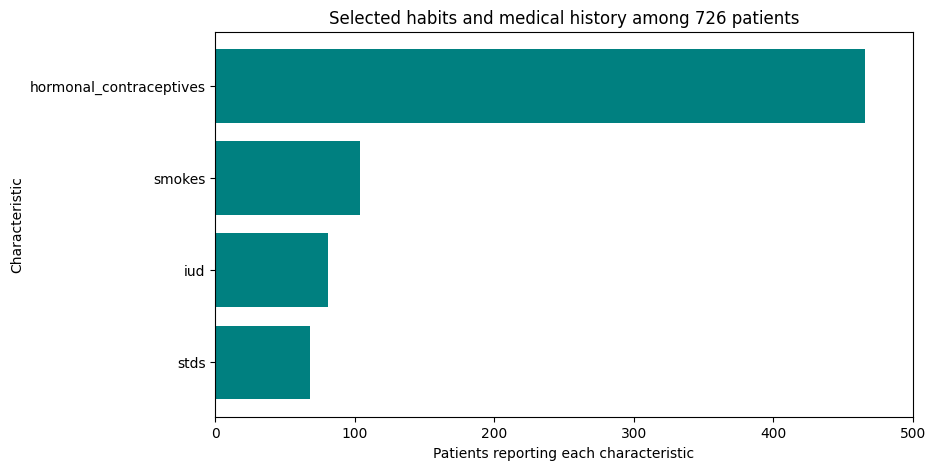

In [11]:
plt.figure(figsize=(9, 5))

plt.barh(
    plot_data.index,
    plot_data['yes'],
    color='teal'
)

plt.xlabel('Patients reporting each characteristic')
plt.ylabel('Characteristic')
plt.title('Selected habits and medical history among 726 patients')
plt.xlim(0, 500)


###Key Insights:

- Hormonal contraceptive use was the most common characteristic, reported by 466 of the 726 patients, which is about 64.19% of our valid population.
- Smoking was reported by 104 patients, about 14.33% of our valid population. This is followed by IUD use with 81 patients, which is 11.16% and a hisotry of STDs with 68 patients, 9.37%.

##3. [How different is the percentage of positive biopsy results between patients with and without a reported history of STIs?](#scrollTo=43hJ2_zQXoFU)


In [12]:
dfbiopsy = pd.pivot_table(
    data_clean,
    values='biopsy',
    index='stds',
    aggfunc=['sum', 'count'],
)

dfbiopsy['negative biopsy'] = (
    dfbiopsy['count', 'biopsy'] -
    dfbiopsy['sum', 'biopsy']
).round(2)

dfbiopsy['positive biopsy percentage'] = (
    dfbiopsy['sum', 'biopsy'] /
    dfbiopsy['count', 'biopsy'] * 100
).round(2)


dfbiopsy['negative biopsy percentage'] = (
    dfbiopsy['negative biopsy'] /
    dfbiopsy['count', 'biopsy'] * 100
).round(2)

dfbiopsy

,sum,count,negative biopsy,positive biopsy percentage,negative biopsy percentage
,biopsy,biopsy,,,
stds,,,,,
0.0,39,658,619,5.93,94.07
1.0,11,68,57,16.18,83.82


In [13]:
pie_data = dfbiopsy.loc[:, [
    'positive biopsy percentage',
    'negative biopsy percentage'
]]

pie_data = pie_data.T
pie_data.index = ['Positive', 'Negative']
pie_data.columns = ['No STD history (n = 658)', 'STD history (n = 68)']

pie_data

,No STD history (n = 658),STD history (n = 68)
Positive,5.93,16.18
Negative,94.07,83.82


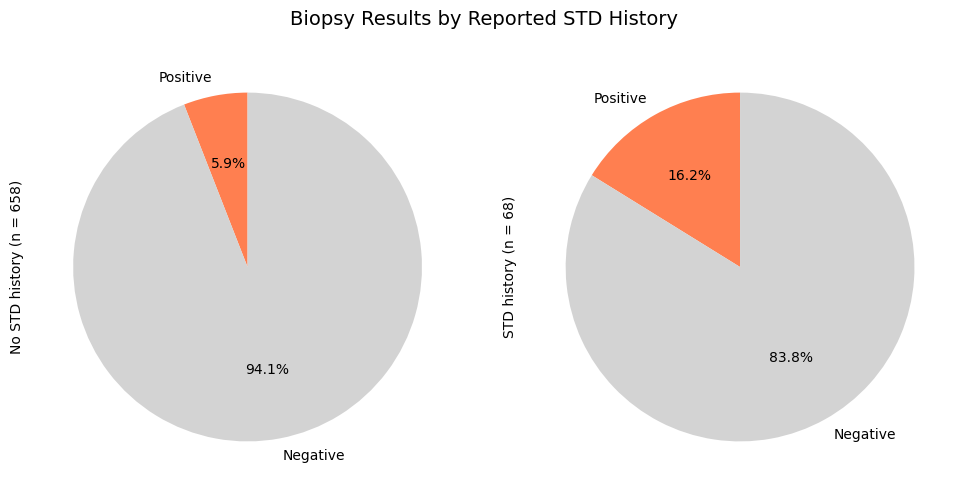

In [15]:
pie_data.plot(
    kind='pie',
    subplots=True,
    figsize=(10, 5),
    autopct='%1.1f%%',
    startangle=90,
    colors=['coral', 'lightgray'],
    legend=False
)
plt.suptitle('Biopsy Results by Reported STD History', fontsize=14)

plt.tight_layout()
plt.show()

###Key Insights:

- Positive biospy results were more frequent among patients with a reported STD history. 11 out of 68 of people who had an STD history, reported a positive biopsy result, which translates to a percentage of 16.18%. Meanwhile, in the population of people who hadn't reported STD history (658 people), only 5.93% presented a positive biopsy result.
- The difference was approximately 10.25 percentage points. This suggests an association within the analyzed sample, but this does not prove that STDs caused the positive biopsy results.
